In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
import numpy as np
import requests
from PIL import Image
from io import BytesIO
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflowjs as tfjs

ModuleNotFoundError: No module named 'tensorflowjs'

In [ ]:
# Function to load and preprocess image from URL
def load_image_from_url(url, target_size=(224, 224)):
    try:
        response = requests.get(url)
        img = Image.open(BytesIO(response.content))
        img = img.convert('RGB')  # Ensure image is RGB
        img = img.resize(target_size)
        img_array = np.array(img)
        img_array = img_array / 255.0  # Normalize
        return img_array
    except Exception as e:
        print(f"Error loading image from {url}: {e}")
        return None

# Fetch data from API and create DataFrame
def fetch_fish_data(api_url, token):
    headers = {
        'Accept': 'application/json',
        'Content-Type': 'application/json',
        'Authorization': f'Bearer {token}'
    }
    
    response = requests.get(
        api_url,
        params={'withImages': 'true'},
        headers=headers
    )
    
    if response.status_code == 200:
        data = response.json()
        paths = []
        labels = []
        
        for fish in data['data']:
            if fish['images']:
                for image in fish['images']:
                    if image.get('url'):
                        paths.append(image['url'])
                        labels.append(fish['genus'])
        
        return pd.DataFrame({'path': paths, 'label': labels})
    else:
        raise Exception(f"API request failed with status {response.status_code}")

Total images found: 12
Unique genera: ['Betta' 'Carassius']
                                                path  label
0  http://localhost:8000/data/images/1_jpg.rf.b6e...  Betta
1  http://localhost:8000/data/images/5_jpg.rf.eb8...  Betta
2  http://localhost:8000/data/images/2-3_jpg.rf.c...  Betta
3  http://localhost:8000/data/images/3_jpg.rf.407...  Betta
4  http://localhost:8000/data/images/ch4_jpg.rf.0...  Betta


In [ ]:
# Function to load and preprocess image from URL
def load_image_from_url(url, target_size=(224, 224)):
    try:
        response = requests.get(url)
        img = Image.open(BytesIO(response.content))
        img = img.convert('RGB')  # Ensure image is RGB
        img = img.resize(target_size)
        img_array = np.array(img)
        img_array = img_array / 255.0  # Normalize
        return img_array
    except Exception as e:
        print(f"Error loading image from {url}: {e}")
        return None

# Fetch data from API and create DataFrame
def fetch_fish_data(api_url, token):
    headers = {
        'Accept': 'application/json',
        'Content-Type': 'application/json',
        'Authorization': f'Bearer {token}'
    }
    
    response = requests.get(
        api_url,
        params={'withImages': 'true'},
        headers=headers
    )
    
    if response.status_code == 200:
        data = response.json()
        paths = []
        labels = []
        
        for fish in data['data']:
            if fish['images']:
                for image in fish['images']:
                    if image.get('url'):
                        paths.append(image['url'])
                        labels.append(fish['genus'])
        
        return pd.DataFrame({'path': paths, 'label': labels})
    else:
        raise Exception(f"API request failed with status {response.status_code}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   path    12 non-null     object
 1   label   12 non-null     object
dtypes: object(2)
memory usage: 320.0+ bytes


In [10]:
df['label']=df['label'].astype('category')

In [11]:
df['label'].value_counts()

label
Carassius    7
Betta        5
Name: count, dtype: int64

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

NameError: name 'load_image_from_url' is not defined

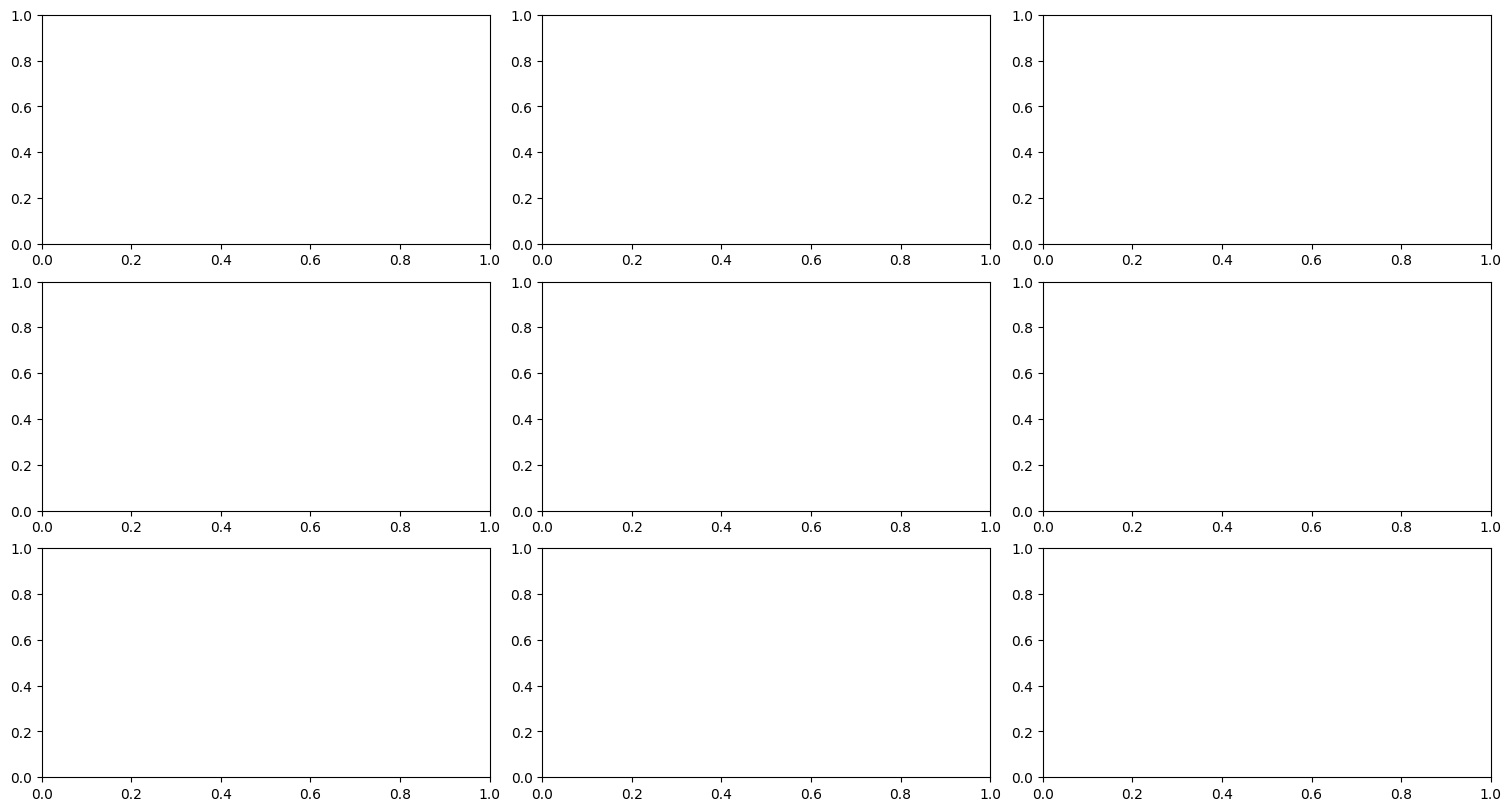

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(15,8), constrained_layout=True)
ax=ax.flatten()
j=0
for i in df['label'].unique():
    
    ax[j].imshow(plt.imread(df[df['label']==i].iloc[0,0]))
    ax[j].set_title(i)
    j=j+1